
载入程序包：'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



载入程序包：'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union



载入程序包：'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


[1] "Candidate Time Points Summary (Step Points):"


date,num_candidates,avg_increase,weighted_avg_increase
<yearmon>,<int>,<dbl>,<dbl>
3月 2018,68,115.57573,114.83245
1月 2018,115,103.87633,92.56065
3月 2021,106,96.98911,88.25278
7月 2019,2,83.75346,85.35358
7月 2021,8,77.08081,82.59717
1月 2013,8,57.60303,82.34691
7月 2020,1,81.71985,81.71985
3月 2013,101,87.26361,81.70475
7月 2012,2,79.95602,79.95602


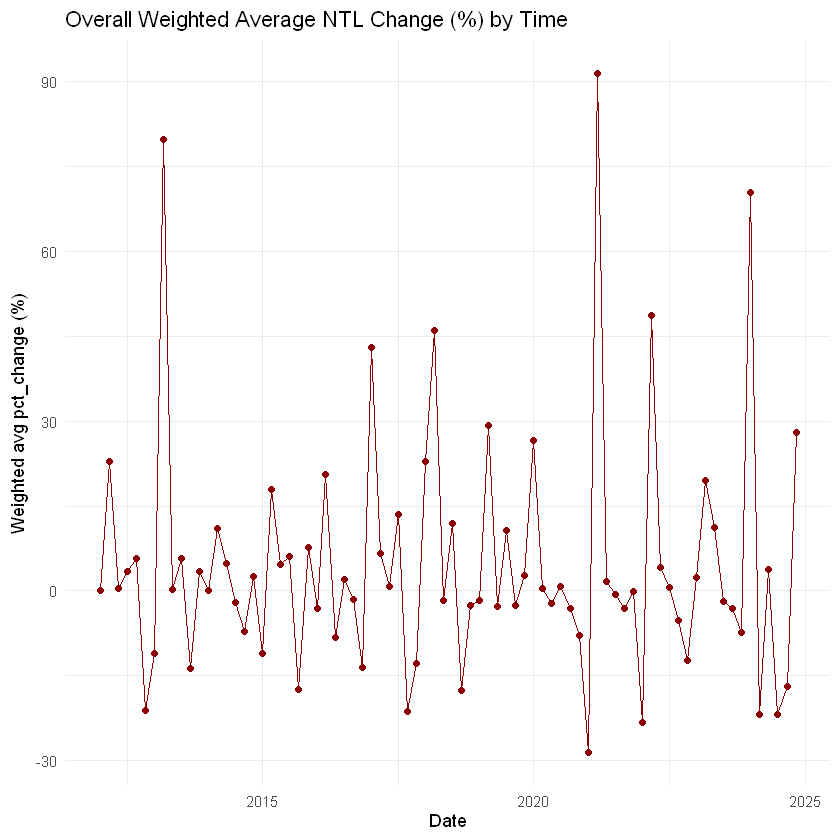

[1] "Best Candidate Time Point (Step Point):"
# A tibble: 1 × 4
  date      num_candidates avg_increase weighted_avg_increase
  <yearmon>          <int>        <dbl>                 <dbl>
1 3月 2018              68         116.                  115.


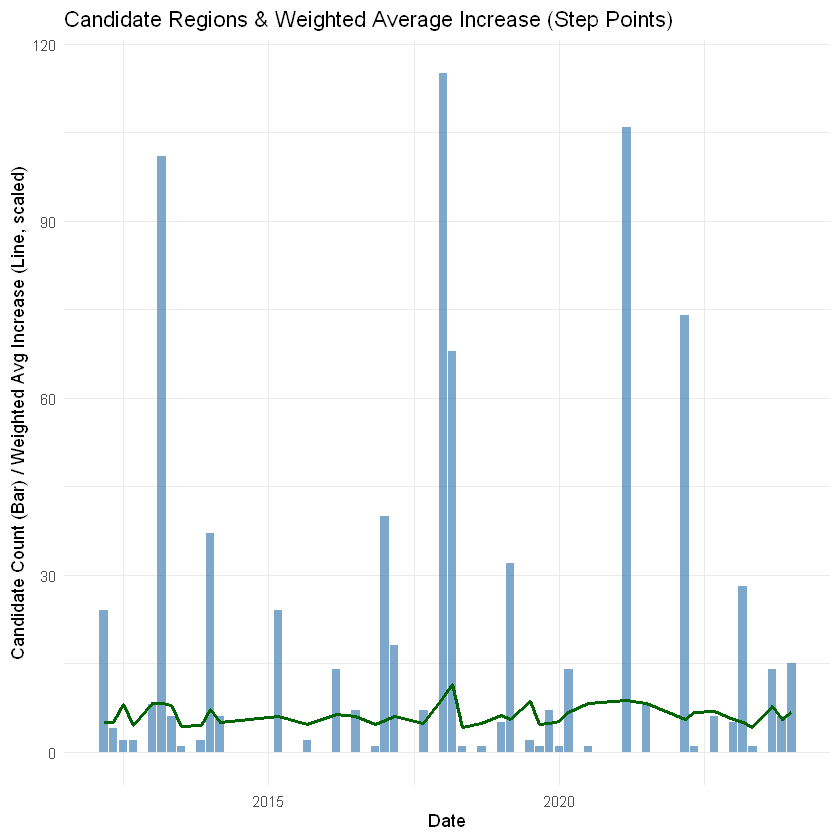

In [1]:
library(dplyr)
library(ggplot2)
library(lubridate)
library(zoo)

# 1. Read data and remove duplicate header rows
raw_data <- read.csv("NTL_data/NASA_ntl_2012_2024_monthly_odd_pct.csv", stringsAsFactors = FALSE)
data <- raw_data[raw_data$name != "name", ]

# 2. Data type conversion
data$name <- as.character(data$name)
data$population <- as.numeric(data$population)
data$population_density <- as.numeric(data$population_density)
data$ntl_mean <- as.numeric(data$ntl_mean)
data$n_pixels <- as.numeric(data$n_pixels)
data$n_non_na_pixels <- as.numeric(data$n_non_na_pixels)
data$prop_non_na_pixels <- as.numeric(data$prop_non_na_pixels)
data$date <- as.yearmon(data$date, "%Y-%m")
data$pct_change <- as.numeric(data$pct_change)

# 3. Threshold setting
threshold_increase <- 40    # Current month's pct_change must reach at least 40%
threshold_drop     <- 10    # Next period's pct_change should not be lower than 10%

# 4. Candidate area filtering - upgraded requirements: not only the next period (lead1)
#    but also the period after (lead2) must have ntl_mean not less than 90% of the candidate point
candidate_data <- data %>%
  arrange(name, date) %>%
  group_by(name) %>%
  mutate(
    next_pct_change = lead(pct_change),
    lead1_ntl_mean = lead(ntl_mean),
    lead2_ntl_mean = lead(ntl_mean, 2)
  ) %>%
  ungroup() %>%
  # First exclude records where current pct_change is NA
  filter(!is.na(pct_change)) %>%
  # Ensure current pct_change meets the increase threshold, and next period's change (if exists) is not below threshold
  filter(pct_change >= threshold_increase & (is.na(next_pct_change) | next_pct_change >= threshold_drop)) %>%
  # New requirement: must have at least two subsequent periods of data, and both periods must have ntl_mean not less than 90% of candidate period
  filter(!is.na(lead1_ntl_mean) & !is.na(lead2_ntl_mean) &
           (lead1_ntl_mean >= ntl_mean * 0.9) &
           (lead2_ntl_mean >= ntl_mean * 0.9))

# 5. Summarize candidate areas (aggregated by month)
candidate_summary <- candidate_data %>%
  group_by(date) %>%
  summarise(
    num_candidates = n(),
    avg_increase = mean(pct_change, na.rm = TRUE),
    weighted_avg_increase = sum(pct_change * n_non_na_pixels, na.rm = TRUE) / sum(n_non_na_pixels, na.rm = TRUE)
  ) %>%
  arrange(desc(weighted_avg_increase)) %>%
  ungroup()

# 6. Summarize overall data (all areas, regardless of whether they're candidates)
overall_summary <- data %>%
  group_by(date) %>%
  summarise(
    avg_pct_change = mean(pct_change, na.rm = TRUE),
    weighted_avg_pct_change = sum(pct_change * n_non_na_pixels, na.rm = TRUE) / sum(n_non_na_pixels, na.rm = TRUE),
    sd_pct_change = sd(pct_change, na.rm = TRUE),
    count = n()
  ) %>%
  ungroup()

# 7. Create plots
p1 <- ggplot(overall_summary, aes(x = as.Date(date), y = weighted_avg_pct_change)) +
  geom_line(color = "darkred") +
  geom_point(color = "darkred") +
  labs(title = "Overall Weighted Average NTL Change (%) by Time",
       x = "Date",
       y = "Weighted avg pct_change (%)") +
  theme_minimal()

p2 <- ggplot(candidate_summary, aes(x = as.Date(date))) +
  geom_bar(aes(y = num_candidates), stat = "identity", fill = "steelblue", alpha = 0.7) +
  geom_line(aes(y = weighted_avg_increase / 10), color = "darkgreen", size = 1) +
  labs(title = "Candidate Regions & Weighted Average Increase (Step Points)",
       x = "Date",
       y = "Candidate Count (Bar) / Weighted Avg Increase (Line, scaled)") +
  theme_minimal()

print("Candidate Time Points Summary (Step Points):")
candidate_summary

print(p1)
print(p2)

# 8. Select the candidate time point with the highest weighted average change (Step Point)
best_candidate <- candidate_summary %>% arrange(desc(weighted_avg_increase)) %>% slice(1)
print("Best Candidate Time Point (Step Point):")
print(best_candidate)


# Analysis of Nighttime Light vs Crime Rate Relationship

This code performs an analysis to explore the potential relationship between nighttime light (NTL) changes and crime rates in Vancouver (whole area)

'data.frame':	78 obs. of  6 variables:
 $ YEAR            : int  2012 2012 2012 2012 2012 2012 2013 2013 2013 2013 ...
 $ MONTH           : int  1 3 5 7 9 11 1 3 5 7 ...
 $ crime_count     : int  1585 1515 1374 1346 1456 1722 1485 1567 1468 1463 ...
 $ date            : chr  "1月 2012" "3月 2012" "5月 2012" "7月 2012" ...
 $ prev_crime_count: int  NA 1585 1515 1374 1346 1456 1722 1485 1567 1468 ...
 $ pct_change      : num  NA -4.42 -9.31 -2.04 8.17 ...
'data.frame':	78 obs. of  6 variables:
 $ date                  : chr  "1月 2012" "3月 2012" "5月 2012" "7月 2012" ...
 $ total_ntl             : num  16507 19082 18429 18775 20610 ...
 $ total_pixels          : int  3650 3853 3868 3868 3868 3434 3862 3861 3865 3825 ...
 $ weighted_ntl_mean     : num  4.52 4.95 4.76 4.85 5.33 ...
 $ prev_weighted_ntl_mean: num  NA 4.52 4.95 4.76 4.85 ...
 $ pct_change            : num  NA 9.51 -3.79 1.88 9.77 ...


,date,YEAR,MONTH,crime_count,prev_crime_count,pct_change.x,total_ntl,total_pixels,weighted_ntl_mean,prev_weighted_ntl_mean,pct_change.y
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,11月 2012,2012,11,1722,1456,18.269231,13794.15,3434,4.016933,5.328384,-24.612539
2,11月 2013,2013,11,1805,1392,29.669540,19505.22,3849,5.067608,5.248692,-3.450079
3,11月 2014,2014,11,1892,1973,-4.105423,18916.20,3865,4.894229,5.221492,-6.267616
4,11月 2015,2015,11,2262,1706,32.590856,18711.54,3868,4.837522,4.462879,8.394657
5,11月 2016,2016,11,1943,1922,1.092612,14473.16,3864,3.745641,4.422286,-15.300798
6,11月 2017,2017,11,2398,2034,17.895772,14729.56,3825,3.850866,4.394427,-12.369335



Call:
lm(formula = pct_change.x ~ pct_change.y, data = merged_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-46.453  -7.985   1.480   6.738  32.747 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept)   0.90865    1.39490   0.651   0.5168  
pct_change.y -0.12678    0.06675  -1.899   0.0614 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 12.19 on 75 degrees of freedom
Multiple R-squared:  0.04589,	Adjusted R-squared:  0.03317 
F-statistic: 3.607 on 1 and 75 DF,  p-value: 0.06137


`geom_smooth()` using formula = 'y ~ x'


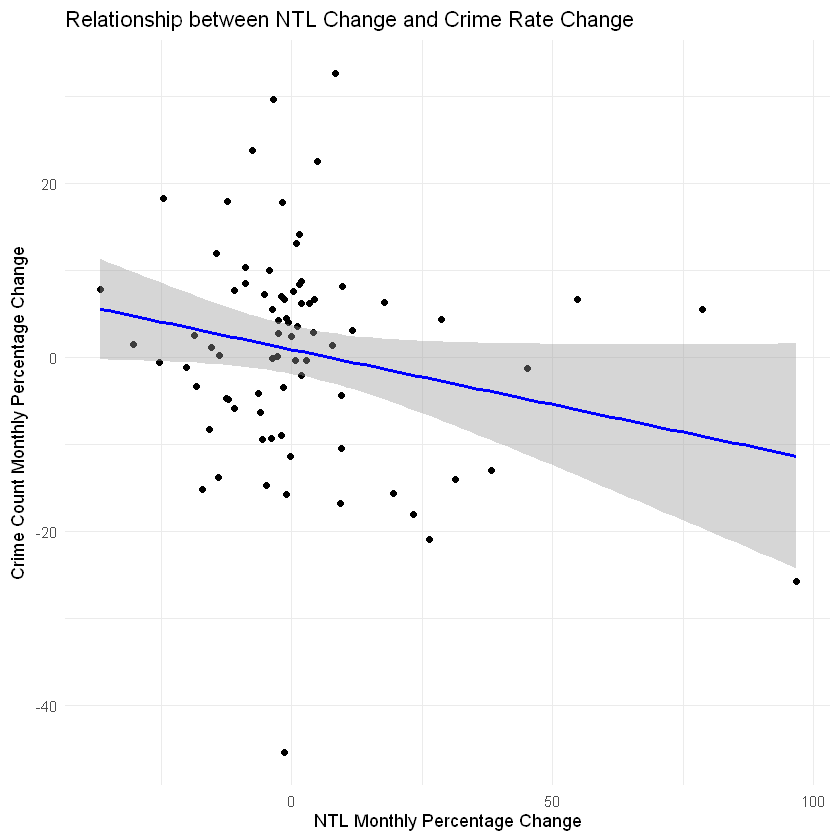

In [ ]:
# Load necessary packages
library(ggplot2)
library(dplyr)

# Read data, adjust file paths as needed
crime_data <- read.csv("Processed_Aggregate_Crime_data/crime_night_monthly_pct_change_van.csv", stringsAsFactors = FALSE)
ntl_data <- read.csv("NTL_data/ntl_vancouver_monthly_pct_change.csv", stringsAsFactors = FALSE)

# View data structure (optional)
str(crime_data)
str(ntl_data)

# Since both datasets have a date variable (format similar to "1月 2012"), we can use it to merge the data
merged_data <- merge(crime_data, ntl_data, by = "date")

# Check merge results
head(merged_data)

# Note:
# In the merged data, variables with the same name from both files will automatically get .x and .y suffixes
# Here, crime data percent change is pct_change.x, ntl is pct_change.y

# Remove rows containing NA (usually the first period data may be NA)
merged_data <- merged_data %>% 
  filter(!is.na(pct_change.x) & !is.na(pct_change.y))

# Run linear regression, using NTL percent change to predict crime rate percent change
reg_model <- lm(pct_change.x ~ pct_change.y, data = merged_data)
summary(reg_model)

# Create scatter plot with regression line
ggplot(merged_data, aes(x = pct_change.y, y = pct_change.x)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(x = "NTL Monthly Percentage Change", y = "Crime Count Monthly Percentage Change",
       title = "Relationship between NTL Change and Crime Rate Change") +
  theme_minimal()
